In [1]:
from glob import glob

from collections import defaultdict
import numpy as np
import json
from _analysis import get_fid
import polars as pl
from sewar import msssim
from PIL import Image
from pathlib import Path
import tempfile
import io

from _plotting import plot_tradeoff

%load_ext autoreload
%autoreload 2

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/lpips/weights/v0.1/vgg.pth


/home/weissl/miniconda3/envs/hynea/lib/python3.12/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path,

## Get runtime data points

In [16]:
usr_dir = "/home/weissl"
stats = glob(f"{usr_dir}/Projects/SMOO/defaults/hynea/_sweep_ca/*_runs/*/*/stats.json")

In [17]:
results = defaultdict(list)
for s in stats:
    key = s.split("_runs")[0].split("/")[-1]
    with open(s, "rb") as f:
        data = json.load(f)
    results[key].append(data["runtime"])

In [18]:
key_map = {float(k.split("_")[0]):k for k in results.keys()}

## Get SSIM data

In [2]:
usr_dir = "/home/weissl"
origins = glob(f"{usr_dir}/Projects/SMOO/defaults/hynea/_sweep_ca/*_runs/*/*/origin*.png")
targets = glob(f"{usr_dir}/Projects/SMOO/defaults/hynea/_sweep_ca/*_runs/*/*/taget*.png")

In [20]:
ssims = defaultdict(list)
for o, t in zip(origins, targets):
    key = o.split("_runs")[0].split("/")[-1]
    img1 = np.array(Image.open(o).convert("RGB"))
    img2 = np.array(Image.open(t).convert("RGB"))
    ssims[key].append(msssim(img1, img2).real)

## Get FID

In [21]:
path = Path("celeba_full.parquet")
if not path.exists():
    df = pl.read_parquet('hf://datasets/flwrlabs/celeba/img_align+identity+attr/valid-*.parquet')
    df = df.with_columns([
        pl.col("image").struct.field("bytes").alias("image_bytes"),
        pl.col("image").struct.field("path").alias("image_filename")
    ])
    df.write_parquet(path)
else:
    df = pl.read_parquet(path)

tmp_dir = Path(tempfile.mkdtemp())
imagenet_paths = []
for row in df.iter_rows(named=True):
    img = Image.open(io.BytesIO(row["image_bytes"])).convert("RGB")
    if img.size != (256, 256):
        img = img.resize((256, 256), Image.BILINEAR)
    path_file = tmp_dir / (Path(row["image_filename"]).stem + ".jpg")
    img.save(path_file, format="JPEG", quality=95)
    imagenet_paths.append(str(path_file))

In [22]:
sweep_path = "/home/weissl/Projects/SMOO/defaults/hynea/_sweep_ca/"
fid_by_lr = {}

for lr_dir in glob(f"{sweep_path}/*_runs"):
    lr_config = lr_dir.split("/")[-1].replace("_runs", "")
    targets = sorted(glob(f"{lr_dir}/*/*/taget*.png"))

    if targets:
        fid_score = get_fid(imagenet_paths, targets)
        fid_by_lr[lr_config]  = float(fid_score)

100%|██████████| 156/156 [00:30<00:00,  5.15it/s]


100%|██████████| 1/1 [00:00<00:00,  3.15it/s]


100%|██████████| 1/1 [00:00<00:00,  3.47it/s]


100%|██████████| 1/1 [00:00<00:00,  3.37it/s]


100%|██████████| 1/1 [00:00<00:00,  3.32it/s]


100%|██████████| 1/1 [00:00<00:00,  3.36it/s]


100%|██████████| 1/1 [00:00<00:00,  3.34it/s]


100%|██████████| 1/1 [00:00<00:00,  3.30it/s]


100%|██████████| 1/1 [00:00<00:00,  3.30it/s]


100%|██████████| 1/1 [00:00<00:00,  3.30it/s]


## Plot

In [23]:
runt = [np.array(results[key_map[kr]]) for kr in sorted(key_map.keys())]
qual = [np.array(fid_by_lr[key_map[kr]]) for kr in sorted(key_map.keys())]
ssim = [np.array(ssims[key_map[kr]]) for kr in sorted(key_map.keys())]
ticks = [r"$\rightarrow$".join(key_map[kr].split("_")) for kr in sorted(key_map.keys())]

left_m = [(runt, "Runtime (sec)", (0-5000 * 0.01, 5000*1.01))]
right_m = [(qual, "FID", (159, 261)), (ssim, "MS-SSIM", (-0.01, 1.01))]

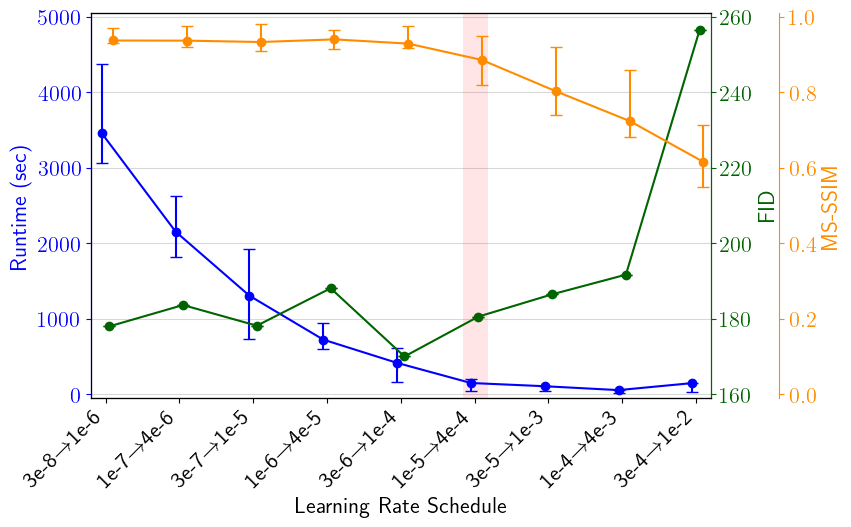

In [24]:
plot_tradeoff(left_m, right_m, ticks, colors=["blue", "darkgreen", "darkorange"], name="CelebA", vline=5)

### Plot Examples